<a href="https://colab.research.google.com/github/karenmacambira/MVP/blob/main/Karen_MVP_ML_%26_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# MVP: *Machine Learning & Analytics*
**Autor:** KAREN MACAMBIRA FERREIRA

**Data:** 24/09/2025

**Matrícula:**  4052024002461

**Dataset:** https://github.com/karenmacambira/MVP/blob/main/listings.zip




## ✅ Checklist do MVP (o que precisa conter)
- [x] **Problema definido** e contexto de negócio
- [x] **Carga e preparação** dos dados (sem vazamento de dados)
- [x] **Divisão** em treino/validação/teste (ou validação cruzada apropriada)
- [x] **Tratamento**: limpeza, transformação e **engenharia de atributos**
- [x] **Modelagem**: comparar abordagens/modelos (com **baseline**)
- [x] **Otimização de hiperparâmetros**
- [x] **Avaliação** com **métricas adequadas** e discussão de limitações
- [x] **Boas práticas**: seeds fixas, tempo de treino, recursos computacionais, documentação
- [x] **Pipelines reprodutíveis** (sempre que possível)



## 1. Escopo, objetivo e definição do problema

**Contexto do Problema:**
A precificação de um anúncio no Airbnb é uma decisão crítica para os anfitriões. Um preço muito alto pode afastar hóspedes em potencial, resultando em baixa ocupação e menor receita. Um preço muito baixo, por outro lado, pode maximizar a ocupação, mas não necessariamente a rentabilidade, além de poder atrair hóspedes indesejados. Muitos anfitriões, especialmente os novos, têm dificuldade em determinar o preço ideal com base nas características do imóvel, localização, comodidades e sazonalidade.

**Objetivo:**
Desenvolver um modelo de Machine Learning capaz de prever o preço diário (preço da diária) de um imóvel listado no Airbnb com base em suas características (como número de quartos, localização, tipo de propriedade, comodidades oferecidas, avaliações anteriores, etc.). O modelo ajudará anfitriões a definir um preço inicial mais assertivo e baseado em dados.

**Tipo de Tarefa:** Regressão

Justificativa: A variável alvo (target) que queremos prever é o preço da diária, que é uma variável numérica contínua. Portanto, a tarefa é prever um valor numérico, caracterizando um problema de regressão.

**Área de Aplicação:** Dados Tabulares

Justificativa: Os dados do Airbnb são tipicamente estruturados em formato de tabela (planilha ou banco de dados), onde cada linha representa um imóvel (uma instância) e cada coluna representa uma característica desse imóvel (uma feature), como numero_de_quartos, bairro, wifi, numero_de_avaliacoes, etc. O modelo aprenderá padrões a partir dessas features tabulares para fazer a previsão.

**Valor para o Anfitrião (Usuário):**

- Maximização da Receita: Uma precificação mais precisa evita períodos de ociosidade (preço alto) e maximiza o ganho por diária (evitando preços baixos desnecessários), aumentando a receita total no longo prazo.

- Competitividade: Permite que o anúncio se mantenha competitivo em relação a imóveis similares na mesma região, atraindo mais hóspedes.

- Redução de Incerteza e Ganho de Eficiência: Automatiza e embasa a decisão de precificação, que muitas vezes é feita de forma intuitiva e demorada, especialmente para anfitriões com múltiplos imóveis.

**Valor para a Plataforma Airbnb (Negócio):**

- Maior Satisfação do Usuário: Anfitriões satisfeitos com os resultados financeiros são mais propensos a permanecer ativos na plataforma.

- Otimização do Marketplace: Preços adequados levam a uma melhor alocação da demanda, melhorando a experiência geral dos hóspedes, que encontram opções com melhor custo-benefício.

- Ferramenta de Valor Agregado: O Airbnb poderia oferecer uma funcionalidade de "precificação inteligente" como um benefício para anfitriões premium ou para atrair novos usuários para a plataforma.


## 2. Reprodutibilidade e ambiente


In [90]:
# 1. IMPORTAR BIBLIOTECAS
import sys
import warnings
import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, cross_validate, GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.svm import SVR

try:
    from xgboost import XGBRegressor
    XGB_INSTALADO = True
    print("✅ XGBoost instalado e importado")
except ImportError:
    XGB_INSTALADO = False
    print("❌ XGBoost não instalado. Vamos pular este algoritmo.")

print("✅ Todas as bibliotecas importadas com sucesso!")
# 2. DEFINIR A SEED
SEED = 42

print("Python:", sys.version.split()[0])
print("Seed global:", SEED)

# Pandas: mostrar mais colunas sem quebrar linhas
pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', 50)
pd.set_option('display.expand_frame_repr', False)

✅ XGBoost instalado e importado
✅ Todas as bibliotecas importadas com sucesso!
Python: 3.12.11
Seed global: 42



## 3. Dados: carga, entendimento e qualidade
**Seleção de dados:** Os dados foram extraídos do arquivo dataframe.csv (https://github.com/karenmacambira/MVP/blob/main/dataframe.csv). Esse arquivo foi gerado através de alguns tratamentos realizados no MVP de Análise Exploratória de Dados, cujos dados foram baixados do arquivo listings.csv no site: https://insideairbnb.com/get-the-data/ e salvos no github https://github.com/karenmacambira/MVP/blob/main/listings.zip

Atributos do Dataset
- id : Identificador do imóvel. (int64 )
- latitude : Latitude do imóvel. (float64 )
- longitude : Longitude do imóvel. (float64 )
- accommodates : Número de acomodações do imóvel. (int64 )
- price : Preço da diária do imóvel. (float64 )
- number_of_reviews : Número de avaliações que o imóvel teve. (int64 )
- review_scores_rating : Nota baseada nas avaliações que o imóvel teve. (float64 )
- reviews_per_month : Média de avaliações por mês que o imóve recebeu. (float64 )
- host_is_superhost : Indica se o host é um superhost (t) ou não (f). (object )
- neighbourhood_cleansed : Bairro do imóvel. (object )
- room_type : Tipo do imóvel. Pode ser Entire home/apt, hotel room, private room ou shared room. (object )


In [56]:
# === Carga dos dados ===

# Ignora todos os warnings
warnings.filterwarnings('ignore')

# Caminho do arquivo no git
url = "https://raw.githubusercontent.com/karenmacambira/MVP/main/dataframe.csv"

df = pd.read_csv(url)

# Mostra as primeiras linhas
df.head()

,id,host_is_superhost,neighbourhood_cleansed,latitude,longitude,room_type,accommodates,price,number_of_reviews,review_scores_rating,reviews_per_month,zona,is_superhost
0,271975,f,Vidigal,-22.99508,-43.23604,Entire home/apt,4,236.0,7,4.14,0.05,Zona Sul,False
1,272335,f,Copacabana,-22.96230,-43.17389,Entire home/apt,4,723.0,367,4.92,2.31,Zona Sul,False
2,272631,t,Copacabana,-22.96750,-43.18666,Private room,2,1146.0,32,5.00,0.25,Zona Sul,True
3,273261,f,Leblon,-22.98632,-43.22936,Entire home/apt,6,6742.0,0,NaN,0.00,Zona Sul,False
4,273363,f,Santa Teresa,-22.91825,-43.17872,Private room,1,61.0,5,5.00,0.04,Zona Sul,False


In [39]:
# === Verificações iniciais ===
display(df.sample(5))
print("\nFormato:", df.shape)
print("\nTipos:")
print(df.dtypes)
print("\nValores ausentes por coluna:")
print(df.isna().sum())


,id,host_is_superhost,neighbourhood_cleansed,latitude,longitude,room_type,accommodates,price,number_of_reviews,review_scores_rating,reviews_per_month,zona,is_superhost
222,764534,f,Copacabana,-22.968980,-43.183250,Entire home/apt,4,250.0,37,4.70,0.25,Zona Sul,False
22040,1036607163621517728,f,Copacabana,-22.985774,-43.190115,Entire home/apt,4,1150.0,4,5.00,1.14,Zona Sul,False
15612,769668080878631230,t,Copacabana,-22.977664,-43.193466,Entire home/apt,4,686.0,8,5.00,0.33,Zona Sul,True
22445,1042989218703696479,f,Barra da Tijuca,-22.998673,-43.347695,Entire home/apt,4,1329.0,9,5.00,0.85,Zona Oeste,False
7486,34234467,t,Leme,-22.962990,-43.172580,Entire home/apt,6,1429.0,63,4.87,0.93,Zona Sul,True



Formato: (35220, 13)

Tipos:
id                          int64
host_is_superhost          object
neighbourhood_cleansed     object
latitude                  float64
longitude                 float64
room_type                  object
accommodates                int64
price                     float64
number_of_reviews           int64
review_scores_rating      float64
reviews_per_month         float64
zona                       object
is_superhost                 bool
dtype: object

Valores ausentes por coluna:
id                           0
host_is_superhost            0
neighbourhood_cleansed       0
latitude                     0
longitude                    0
room_type                    0
accommodates                 0
price                        0
number_of_reviews            0
review_scores_rating      9198
reviews_per_month            0
zona                         0
is_superhost                 0
dtype: int64



### 3.1 Análise exploratória resumida (EDA)


<Axes: >

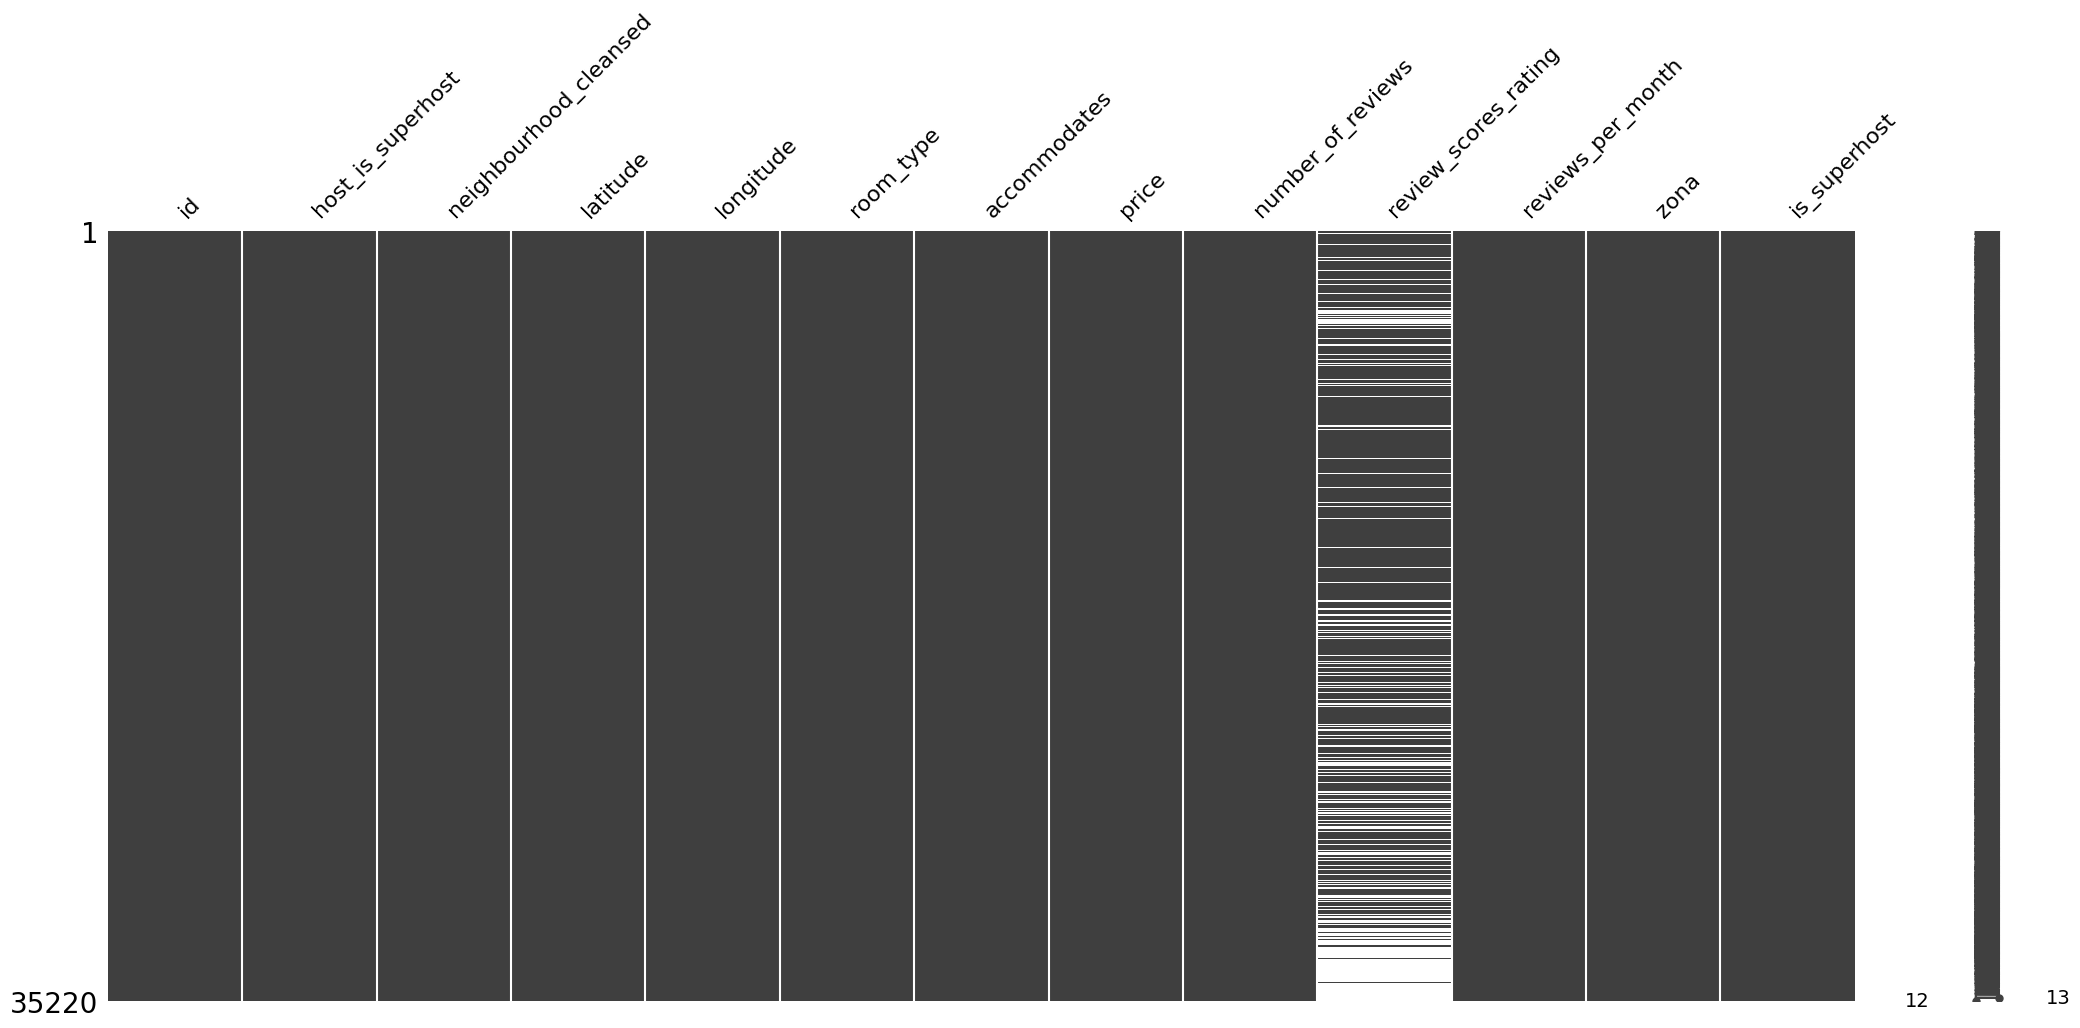

In [40]:
# Função para visualizar o padrão dos dados faltantes
msno.matrix(df)

Os únicos dados faltantes são referentes aos imóveis que não tiveram avaliações.
Para confirmar essa informação, consultaremos se existe algum registro cujo número de reviews seja zero e a avaliação não seja nula.

In [41]:
df_reviews = df[(df['number_of_reviews'] == 0) & (df['review_scores_rating'].notna())]
print(df_reviews)


Empty DataFrame
Columns: [id, host_is_superhost, neighbourhood_cleansed, latitude, longitude, room_type, accommodates, price, number_of_reviews, review_scores_rating, reviews_per_month, zona, is_superhost]
Index: []


O resultado é um dataframe vazio, porque não existem registros nessa condição.


Vamos analisar alguns gráficos

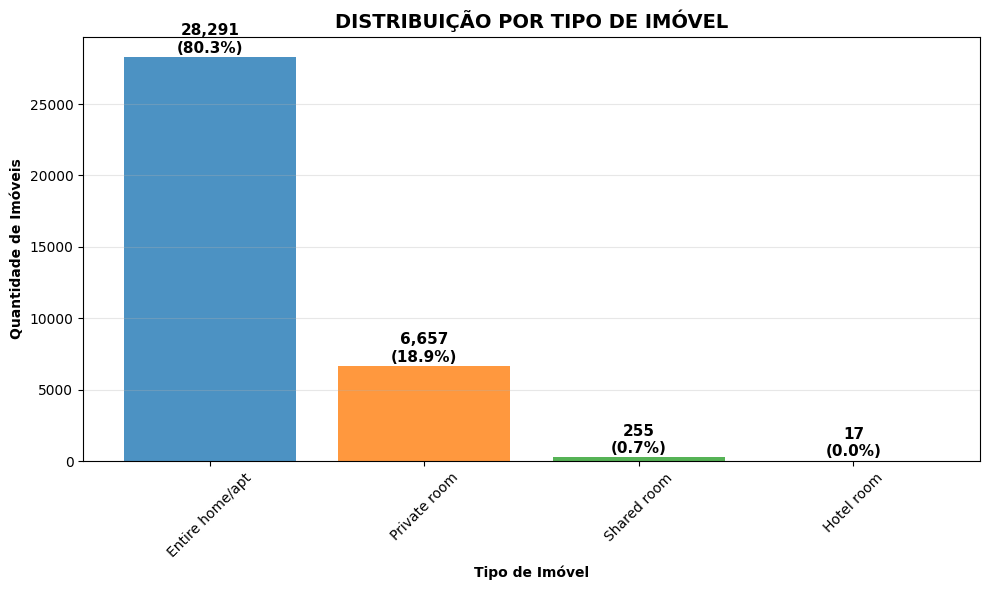

📊 ESTATÍSTICAS - TIPOS DE IMÓVEL:
Total de imóveis: 35,220
Entire home/apt: 28,291 (80.3%)
Private room: 6,657 (18.9%)
Shared room: 255 (0.7%)
Hotel room: 17 (0.0%)


In [42]:
# Gráfico de Tipos de Imóvel
plt.figure(figsize=(10, 6))
room_type_counts = df['room_type'].value_counts()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

bars = plt.bar(room_type_counts.index, room_type_counts.values, color=colors, alpha=0.8)
plt.title('DISTRIBUIÇÃO POR TIPO DE IMÓVEL', fontsize=14, fontweight='bold')
plt.ylabel('Quantidade de Imóveis', fontweight='bold')
plt.xlabel('Tipo de Imóvel', fontweight='bold')
plt.xticks(rotation=45)

# Adicionar valores e porcentagens
total = len(df)
for bar, count in zip(bars, room_type_counts.values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 100,
             f'{count:,}\n({count/total*100:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Estatísticas
print("📊 ESTATÍSTICAS - TIPOS DE IMÓVEL:")
print(f"Total de imóveis: {total:,}")
for tipo, count in room_type_counts.items():
    print(f"{tipo}: {count:,} ({count/total*100:.1f}%)")

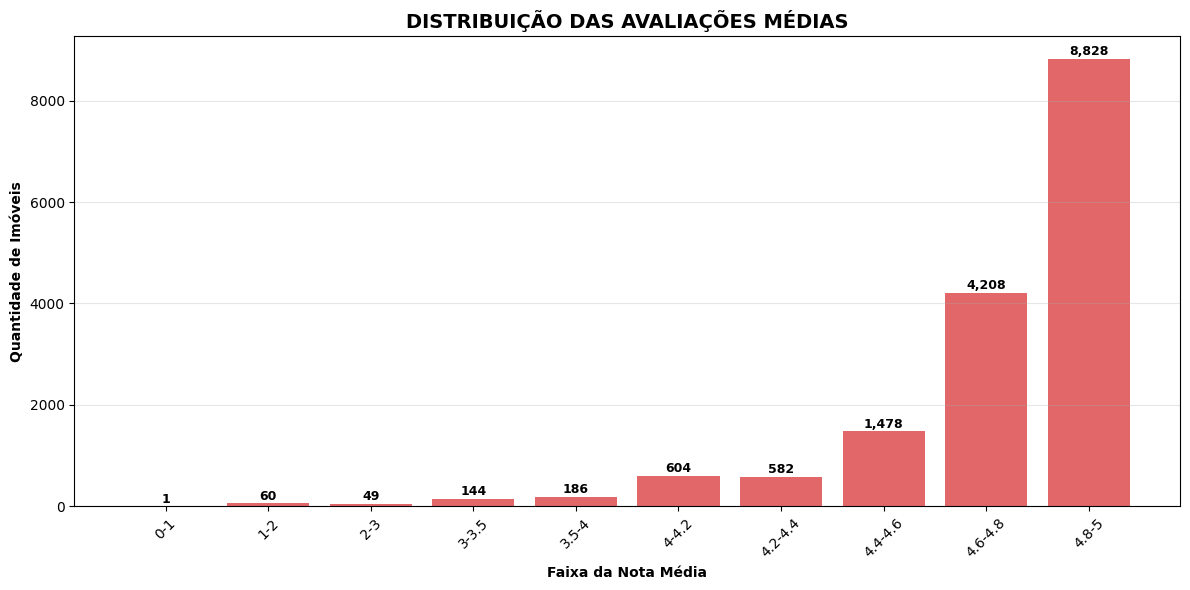

📊 ESTATÍSTICAS DETALHADAS - AVALIAÇÕES:
Total de imóveis na base: 35,220
Imóveis COM avaliação: 26,022 (73.9%)
Imóveis SEM avaliação: 9,198 (26.1%)

📈 Estatísticas das avaliações existentes:
Média: 4.82
Mediana: 4.92
Desvio Padrão: 0.35
Nota mínima: 0.00
Nota máxima: 5.00

📊 Distribuição por faixa de nota:
0-1: 1 imóveis (0.0%)
1-2: 60 imóveis (0.2%)
2-3: 49 imóveis (0.2%)
3-3.5: 144 imóveis (0.6%)
3.5-4: 186 imóveis (0.7%)
4-4.2: 604 imóveis (2.3%)
4.2-4.4: 582 imóveis (2.2%)
4.4-4.6: 1,478 imóveis (5.7%)
4.6-4.8: 4,208 imóveis (16.2%)
4.8-5: 8,828 imóveis (33.9%)


In [36]:
# Gráfico de Avaliações - Versão Corrigida
plt.figure(figsize=(12, 6))

# Tratar dados de avaliação - considerar nulos como "sem avaliação"
df_avaliacoes = df[df['review_scores_rating'].notnull()].copy()

if not df_avaliacoes.empty:
    # Converter para float (já são médias float)
    df_avaliacoes['review_score_numeric'] = pd.to_numeric(df_avaliacoes['review_scores_rating'], errors='coerce')

    # Criar bins para agrupar as notas float (ex: 4.0-4.2, 4.2-4.4, etc)
    bins = [0, 1, 2, 3, 3.5, 4, 4.2, 4.4, 4.6, 4.8, 5]
    labels = ['0-1', '1-2', '2-3', '3-3.5', '3.5-4', '4-4.2', '4.2-4.4', '4.4-4.6', '4.6-4.8', '4.8-5']

    df_avaliacoes['faixa_nota'] = pd.cut(df_avaliacoes['review_score_numeric'], bins=bins, labels=labels, right=False)
    avaliacao_counts = df_avaliacoes['faixa_nota'].value_counts().sort_index()

    # Gráfico de barras
    bars = plt.bar(avaliacao_counts.index.astype(str), avaliacao_counts.values,
                   color='#d62728', alpha=0.7)
    plt.title('DISTRIBUIÇÃO DAS AVALIAÇÕES MÉDIAS', fontsize=14, fontweight='bold')
    plt.ylabel('Quantidade de Imóveis', fontweight='bold')
    plt.xlabel('Faixa da Nota Média', fontweight='bold')
    plt.xticks(rotation=45)

    # Adicionar valores nas barras
    for bar, count in zip(bars, avaliacao_counts.values):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 10,
                 f'{count:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Estatísticas DETALHADAS
    print("📊 ESTATÍSTICAS DETALHADAS - AVALIAÇÕES:")
    print(f"Total de imóveis na base: {len(df):,}")
    print(f"Imóveis COM avaliação: {len(df_avaliacoes):,} ({len(df_avaliacoes)/len(df)*100:.1f}%)")
    print(f"Imóveis SEM avaliação: {len(df) - len(df_avaliacoes):,} ({(len(df) - len(df_avaliacoes))/len(df)*100:.1f}%)")
    print("\n📈 Estatísticas das avaliações existentes:")
    print(f"Média: {df_avaliacoes['review_score_numeric'].mean():.2f}")
    print(f"Mediana: {df_avaliacoes['review_score_numeric'].median():.2f}")
    print(f"Desvio Padrão: {df_avaliacoes['review_score_numeric'].std():.2f}")
    print(f"Nota mínima: {df_avaliacoes['review_score_numeric'].min():.2f}")
    print(f"Nota máxima: {df_avaliacoes['review_score_numeric'].max():.2f}")

    # Distribuição por faixa
    print("\n📊 Distribuição por faixa de nota:")
    for faixa, count in avaliacao_counts.items():
        percent = count/len(df_avaliacoes)*100
        print(f"{faixa}: {count:,} imóveis ({percent:.1f}%)")

else:
    print("⚠️ Não há dados de avaliação disponíveis")
    plt.figure(figsize=(8, 4))
    plt.text(0.5, 0.5, 'SEM DADOS DE AVALIAÇÃO DISPONÍVEIS',
             ha='center', va='center', transform=plt.gca().transAxes, fontsize=14)
    plt.title('DISTRIBUIÇÃO DAS AVALIAÇÕES', fontsize=14, fontweight='bold')
    plt.show()

In [43]:
# Contagem por nota média (arredondada se necessário)
df['nota_arredondada'] = df['review_scores_rating'].round()
avaliacao_counts = df['nota_arredondada'].value_counts().sort_index()
print("Distribuição por Nota Média:")
print(avaliacao_counts)

# Estatísticas descritivas
print(f"\nEstatísticas das Avaliações:")
print(f"Média: {df['review_scores_rating'].mean():.2f}")
print(f"Mediana: {df['review_scores_rating'].median():.2f}")
print(f"Desvio Padrão: {df['review_scores_rating'].std():.2f}")

Distribuição por Nota Média:
nota_arredondada
0.0        1
1.0       59
2.0       46
3.0      148
4.0     2287
5.0    23481
Name: count, dtype: int64

Estatísticas das Avaliações:
Média: 4.82
Mediana: 4.92
Desvio Padrão: 0.35


📊 Distribuição de Avaliações (Notas Médias)
- É um preditor forte para preços;
- Notas mais altas geralmente justificam preços premium;
- Maioria das avaliações é satisfatória (entre 4 e 5), o que pode reduzir um pouco o poder preditivo;
- Recomendação: usar média + métricas de distribuição (desvio padrão, % de notas 5).


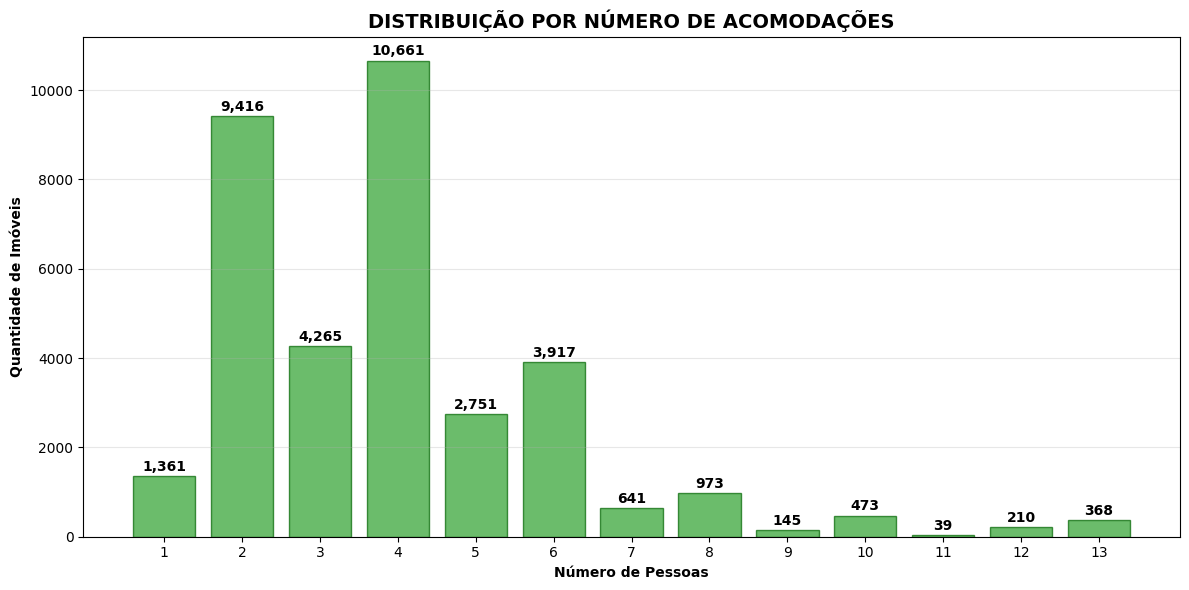

📊 ESTATÍSTICAS - ACOMODAÇÕES:
Capacidade mais comum: 1 pessoas (1,361 imóveis)
Faixa: 1 a 16 pessoas
Total de imóveis: 35,220


In [44]:
# Gráfico de Acomodações
plt.figure(figsize=(12, 6))
accommod_counts = df['accommodates'].value_counts().sort_index()

# Filtrar para melhor visualização (até 12 pessoas + agrupar resto)
accommod_main = accommod_counts[accommod_counts.index <= 12]
if len(accommod_counts) > len(accommod_main):
    others_count = accommod_counts[accommod_counts.index > 12].sum()
    accommod_main[13] = others_count  # 13 representa "13+"

bars = plt.bar(accommod_main.index.astype(str), accommod_main.values,
               color='#2ca02c', alpha=0.7, edgecolor='darkgreen')
plt.title('DISTRIBUIÇÃO POR NÚMERO DE ACOMODAÇÕES', fontsize=14, fontweight='bold')
plt.ylabel('Quantidade de Imóveis', fontweight='bold')
plt.xlabel('Número de Pessoas', fontweight='bold')

# Adicionar valores nas barras
for bar, count in zip(bars, accommod_main.values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 50,
             f'{count:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Estatísticas
print("📊 ESTATÍSTICAS - ACOMODAÇÕES:")
print(f"Faixa: {df['accommodates'].min()} a {df['accommodates'].max()} pessoas")
print(f"Total de imóveis: {len(df):,}")

In [12]:
# Contagem por número de acomodações
accommodates_counts = df['accommodates'].value_counts().sort_index()
print("Distribuição por Acomodações:")
print(accommodates_counts)

# Em porcentagem
accommodates_pct = df['accommodates'].value_counts(normalize=True) * 100
print("\nDistribuição Percentual:")
print(accommodates_pct.round(2))

Distribuição por Acomodações:
accommodates
1      1361
2      9416
3      4265
4     10661
5      2751
6      3917
7       641
8       973
9       145
10      473
11       39
12      210
13       25
14       66
15       72
16      205
Name: count, dtype: int64

Distribuição Percentual:
accommodates
4     30.27
2     26.73
3     12.11
6     11.12
5      7.81
1      3.86
8      2.76
7      1.82
10     1.34
12     0.60
16     0.58
9      0.41
15     0.20
14     0.19
11     0.11
13     0.07
Name: proportion, dtype: float64


👥 Distribuição de Acomodações

- Padrão: Bimodal (picos em 2 e 4 pessoas), 85% entre 2-6 pessoas;
- Distribuição excelente para modelagem - tem variedade suficiente para capturar diferentes faixas de preço, mas com concentração onde o mercado realmente opera.


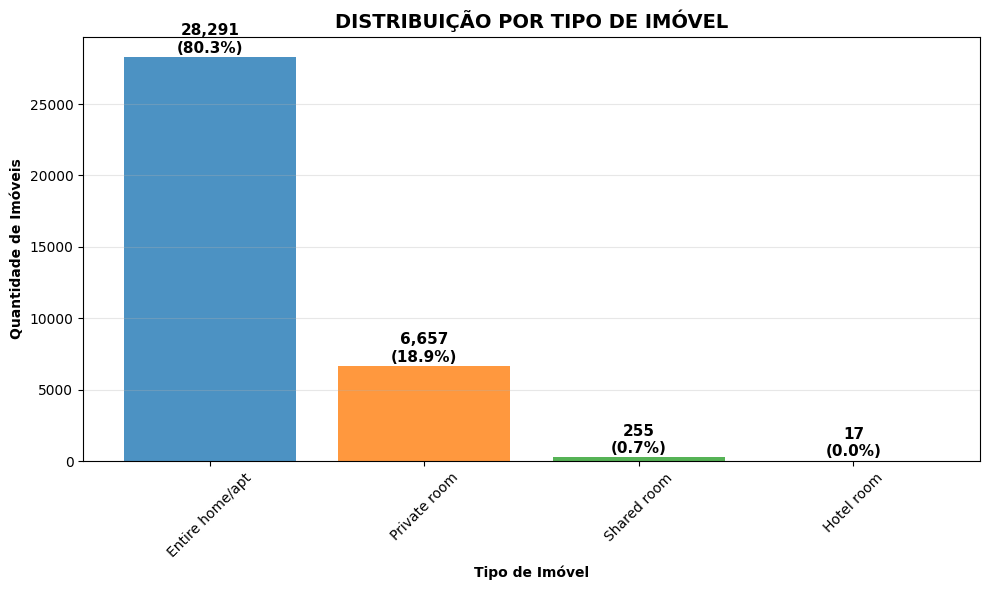

📊 ESTATÍSTICAS - TIPOS DE IMÓVEL:
Total de imóveis: 35,220
Entire home/apt: 28,291 (80.3%)
Private room: 6,657 (18.9%)
Shared room: 255 (0.7%)
Hotel room: 17 (0.0%)


In [45]:
# Gráfico de Tipos de Imóvel
plt.figure(figsize=(10, 6))
room_type_counts = df['room_type'].value_counts()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

bars = plt.bar(room_type_counts.index, room_type_counts.values, color=colors, alpha=0.8)
plt.title('DISTRIBUIÇÃO POR TIPO DE IMÓVEL', fontsize=14, fontweight='bold')
plt.ylabel('Quantidade de Imóveis', fontweight='bold')
plt.xlabel('Tipo de Imóvel', fontweight='bold')
plt.xticks(rotation=45)

# Adicionar valores e porcentagens
total = len(df)
for bar, count in zip(bars, room_type_counts.values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 100,
             f'{count:,}\n({count/total*100:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Estatísticas
print("📊 ESTATÍSTICAS - TIPOS DE IMÓVEL:")
print(f"Total de imóveis: {total:,}")
for tipo, count in room_type_counts.items():
    print(f"{tipo}: {count:,} ({count/total*100:.1f}%)")

In [46]:
# Contagem por tipo de imóvel
room_type_counts = df['room_type'].value_counts().sort_index()
print("Distribuição por Tipo de Imóvel:")
print(room_type_counts)

# Em porcentagem
room_type_pct = df['room_type'].value_counts(normalize=True) * 100
print("\nDistribuição Percentual:")
print(room_type_pct.round(2))

Distribuição por Tipo de Imóvel:
room_type
Entire home/apt    28291
Hotel room            17
Private room        6657
Shared room          255
Name: count, dtype: int64

Distribuição Percentual:
room_type
Entire home/apt    80.33
Private room       18.90
Shared room         0.72
Hotel room          0.05
Name: proportion, dtype: float64


🏠 Tipo de Imóvel (Room Type)
- Variável essencial - impacto direto nos preços;

- Hierarquia típica de valor: Shared room < Private room < Entire home/apt;

- Desafio: Desequilíbrio na distribuição (maioria é "Entire home/apt");

- Solução: Manter a feature com tratamento para categorias minoritárias.

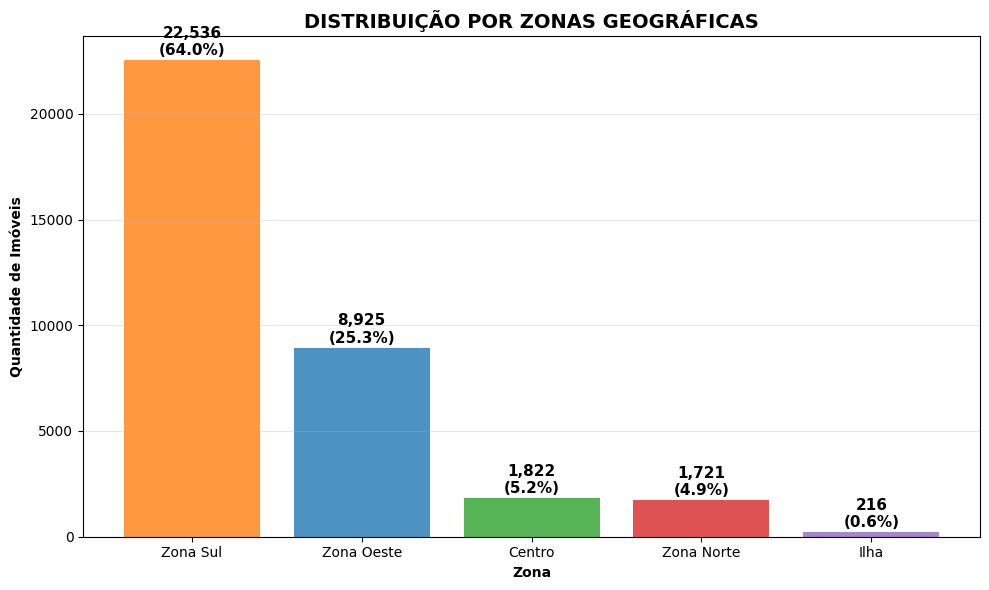

📊 ESTATÍSTICAS - ZONAS GEOGRÁFICAS:
Zona Sul: 22,536 (64.0%)
Zona Oeste: 8,925 (25.3%)
Centro: 1,822 (5.2%)
Zona Norte: 1,721 (4.9%)
Ilha: 216 (0.6%)


In [47]:
# Gráfico de Zonas Geográficas
plt.figure(figsize=(10, 6))
zona_counts = df['zona'].value_counts()
colors = ['#ff7f0e', '#1f77b4', '#2ca02c', '#d62728', '#9467bd']

bars = plt.bar(zona_counts.index, zona_counts.values, color=colors, alpha=0.8)
plt.title('DISTRIBUIÇÃO POR ZONAS GEOGRÁFICAS', fontsize=14, fontweight='bold')
plt.ylabel('Quantidade de Imóveis', fontweight='bold')
plt.xlabel('Zona', fontweight='bold')

# Adicionar valores e porcentagens
total = len(df)
for bar, count in zip(bars, zona_counts.values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 100,
             f'{count:,}\n({count/total*100:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Estatísticas
print("📊 ESTATÍSTICAS - ZONAS GEOGRÁFICAS:")
for zona, count in zona_counts.items():
    print(f"{zona}: {count:,} ({count/total*100:.1f}%)")


## 4. Definição do target, variáveis e divisão dos dados


In [61]:
# 1. Definir target (o que queremos prever)
target = 'price'

# 2. Definir features (variáveis preditoras)
# Excluir colunas que não são features
features = [col for col in df.columns if col not in [target, 'id']]

# 3. Separar X (features) e y (target)
X = df[features]
y = df[target]

print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")
print(f"Target: {target}")
print(f"Features: {features}")

# Dividir em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,  # para reproduzibilidade
    stratify=df['zona']  # manter proporção das zonas em ambos os conjuntos
)

print(f"Treino: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Teste:  X_test {X_test.shape}, y_test {y_test.shape}")

# Verificar tipos de dados
print("=== TIPOS DE FEATURES ===")
print(X_train.dtypes)
print(f"\nNuméricas: {X_train.select_dtypes(include=[np.number]).columns.tolist()}")
print(f"Categóricas: {X_train.select_dtypes(include=['object']).columns.tolist()}")

Shape de X: (35220, 11)
Shape de y: (35220,)
Target: price
Features: ['host_is_superhost', 'neighbourhood_cleansed', 'latitude', 'longitude', 'room_type', 'accommodates', 'number_of_reviews', 'review_scores_rating', 'reviews_per_month', 'zona', 'is_superhost']
Treino: X_train (28176, 11), y_train (28176,)
Teste:  X_test (7044, 11), y_test (7044,)
=== TIPOS DE FEATURES ===
host_is_superhost          object
neighbourhood_cleansed     object
latitude                  float64
longitude                 float64
room_type                  object
accommodates                int64
number_of_reviews           int64
review_scores_rating      float64
reviews_per_month         float64
zona                       object
is_superhost                 bool
dtype: object

Numéricas: ['latitude', 'longitude', 'accommodates', 'number_of_reviews', 'review_scores_rating', 'reviews_per_month']
Categóricas: ['host_is_superhost', 'neighbourhood_cleansed', 'room_type', 'zona']



## 5. Tratamento de dados e **Pipeline** de pré-processamento


In [65]:
# Função para tratar missing values especificamente
def handle_specific_missing(X):
    X_copy = X.copy()

    # review_scores_rating: criar flag + preencher com mediana
    X_copy['rating_missing'] = X_copy['review_scores_rating'].isna().astype(int)
    rating_median = X_copy['review_scores_rating'].median()
    X_copy['review_scores_rating'] = X_copy['review_scores_rating'].fillna(rating_median)

    return X_copy

# Aplicar a função para descobrir as colunas atualizadas
X_train_clean = handle_specific_missing(X_train)
numeric_features = X_train_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train_clean.select_dtypes(include=['object']).columns.tolist()

print("Features numéricas:", numeric_features)
print("Features categóricas:", categorical_features)

# Criar transformers
missing_transformer = FunctionTransformer(handle_specific_missing, validate=False)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # segurança extra
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# PIPELINE FINAL
pipeline = Pipeline(steps=[
    ('handle_missing', missing_transformer),
    ('preprocessor', preprocessor),
    ('feature_selection', SelectKBest(score_func=f_regression, k=15)),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

Features numéricas: ['latitude', 'longitude', 'accommodates', 'number_of_reviews', 'review_scores_rating', 'reviews_per_month', 'rating_missing']
Features categóricas: ['host_is_superhost', 'neighbourhood_cleansed', 'room_type', 'zona']



## 6. Baseline e modelos candidatos



In [66]:
# Baseline 1: Sempre prever a média dos preços
dummy_mean = DummyRegressor(strategy='mean')
dummy_mean.fit(X_train, y_train)
y_pred_baseline = dummy_mean.predict(X_test)

print("=== BASELINE (MÉDIA) ===")
print(f"R²: {r2_score(y_test, y_pred_baseline):.4f}")
print(f"MAE: R$ {mean_absolute_error(y_test, y_pred_baseline):.2f}")
print(f"RMSE: R$ {np.sqrt(mean_squared_error(y_test, y_pred_baseline)):.2f}")
print(f"Previsão sempre: R$ {y_train.mean():.2f}")

=== BASELINE (MÉDIA) ===
R²: -0.0001
MAE: R$ 672.04
RMSE: R$ 1083.95
Previsão sempre: R$ 1015.40


In [68]:
# Baseline 2: Prever a média de preço por zona
dummy_stratified = DummyRegressor(strategy='strategy')
# Vamos criar uma versão manual mais inteligente

class ZonaBaseline:
    def fit(self, X, y):
        self.zona_means = y.groupby(X['zona']).mean()
        return self

    def predict(self, X):
        return X['zona'].map(self.zona_means).fillna(y.mean())

zona_baseline = ZonaBaseline()
zona_baseline.fit(X_train, y_train)
y_pred_zona = zona_baseline.predict(X_test)

print("\n=== BASELINE POR ZONA ===")
print(f"R²: {r2_score(y_test, y_pred_zona):.4f}")
print(f"MAE: R$ {mean_absolute_error(y_test, y_pred_zona):.2f}")
print(f"RMSE: R$ {np.sqrt(mean_squared_error(y_test, y_pred_zona)):.2f}")


=== BASELINE POR ZONA ===
R²: 0.0318
MAE: R$ 650.11
RMSE: R$ 1066.57


In [70]:
# Abordagem 1: Regressão Linear Simples (apenas features numéricas)
numeric_features_simple = ['accommodates', 'latitude', 'longitude', 'number_of_reviews']

X_train_simple = X_train[numeric_features_simple].fillna(0)
X_test_simple = X_test[numeric_features_simple].fillna(0)

# Escalar os dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_simple)
X_test_scaled = scaler.transform(X_test_simple)

# Treinar modelo simples
lr_simple = LinearRegression()
lr_simple.fit(X_train_scaled, y_train)
y_pred_lr = lr_simple.predict(X_test_scaled)

print("\n=== REGRESSÃO LINEAR SIMPLES ===")
print(f"R²: {r2_score(y_test, y_pred_lr):.4f}")
print(f"MAE: R$ {mean_absolute_error(y_test, y_pred_lr):.2f}")
print(f"RMSE: R$ {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.2f}")


=== REGRESSÃO LINEAR SIMPLES ===
R²: 0.2870
MAE: R$ 529.13
RMSE: R$ 915.26


In [71]:
# Abordagem 2: Random Forest com Pipeline Completo (que já montamos)
print("Treinando Random Forest...")
pipeline.fit(X_train, y_train)
y_pred_rf = pipeline.predict(X_test)

print("\n=== RANDOM FOREST (PIPELINE COMPLETO) ===")
print(f"R²: {r2_score(y_test, y_pred_rf):.4f}")
print(f"MAE: R$ {mean_absolute_error(y_test, y_pred_rf):.2f}")
print(f"RMSE: R$ {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.2f}")

Treinando Random Forest...

=== RANDOM FOREST (PIPELINE COMPLETO) ===
R²: 0.2648
MAE: R$ 520.99
RMSE: R$ 929.38



### 6.1 Treino e avaliação rápida (baseline vs candidatos)



In [74]:
# Tabela de comparação COMPLETA
results = {
    'Baseline (Média)': [
        r2_score(y_test, y_pred_baseline),
        mean_absolute_error(y_test, y_pred_baseline),
        np.sqrt(mean_squared_error(y_test, y_pred_baseline))
    ],
    'Baseline (Zona)': [
        r2_score(y_test, y_pred_zona),
        mean_absolute_error(y_test, y_pred_zona),
        np.sqrt(mean_squared_error(y_test, y_pred_zona))
    ],
    'Regressão Linear': [
        r2_score(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_lr),
        np.sqrt(mean_squared_error(y_test, y_pred_lr))
    ],
    'Random Forest': [
        r2_score(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_rf),
        np.sqrt(mean_squared_error(y_test, y_pred_rf))
    ]
}

results_df = pd.DataFrame(results, index=['R²', 'MAE', 'RMSE']).T
print("\n" + "="*60)
print("COMPARAÇÃO FINAL DOS MODELOS")
print("="*60)
print(results_df.round(4))

# Análise dos resultados
print("\n" + "="*60)
print("ANÁLISE DOS RESULTADOS")
print("="*60)

# Melhor modelo por métrica
best_r2 = results_df['R²'].idxmax()
best_mae = results_df['MAE'].idxmin()
best_rmse = results_df['RMSE'].idxmin()

print(f"Melhor R²: {best_r2} ({results_df.loc[best_r2, 'R²']:.4f})")
print(f"Melhor MAE: {best_mae} (R$ {results_df.loc[best_mae, 'MAE']:.2f})")
print(f"Melhor RMSE: {best_rmse} (R$ {results_df.loc[best_rmse, 'RMSE']:.2f})")

# Comparação com baseline
rf_improvement_mae = (results_df.loc['Baseline (Média)', 'MAE'] - results_df.loc['Random Forest', 'MAE']) / results_df.loc['Baseline (Média)', 'MAE'] * 100
rf_improvement_rmse = (results_df.loc['Baseline (Média)', 'RMSE'] - results_df.loc['Random Forest', 'RMSE']) / results_df.loc['Baseline (Média)', 'RMSE'] * 100

print(f"\nMelhoria do Random Forest vs Baseline:")
print(f"Redução do MAE: {rf_improvement_mae:.1f}%")
print(f"Redução do RMSE: {rf_improvement_rmse:.1f}%")


COMPARAÇÃO FINAL DOS MODELOS
                      R²       MAE       RMSE
Baseline (Média) -0.0001  672.0370  1083.9511
Baseline (Zona)   0.0318  650.1133  1066.5691
Regressão Linear  0.2870  529.1256   915.2645
Random Forest     0.2648  520.9880   929.3833

ANÁLISE DOS RESULTADOS
Melhor R²: Regressão Linear (0.2870)
Melhor MAE: Random Forest (R$ 520.99)
Melhor RMSE: Regressão Linear (R$ 915.26)

Melhoria do Random Forest vs Baseline:
Redução do MAE: 22.5%
Redução do RMSE: 14.3%



## 7. Validação e Otimização de Hiperparâmetros



In [75]:
# 1. Validação Cruzada para Regressão (KFold)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

print("=== VALIDAÇÃO CRUZADA (5-FOLD) ===")

# Avaliar o pipeline com validação cruzada
cv_results = cross_validate(
    pipeline, X_train, y_train,
    cv=kfold,
    scoring=['r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error'],
    n_jobs=-1,  # usar todos os processadores
    return_train_score=True
)

# Converter resultados
cv_r2 = cv_results['test_r2']
cv_mae = -cv_results['test_neg_mean_absolute_error']  # converter para positivo
cv_rmse = -cv_results['test_neg_root_mean_squared_error']  # converter para positivo

print(f"R² CV: {cv_r2.mean():.4f} (+/- {cv_r2.std() * 2:.4f})")
print(f"MAE CV: R$ {cv_mae.mean():.2f} (+/- {cv_mae.std() * 2:.2f})")
print(f"RMSE CV: R$ {cv_rmse.mean():.2f} (+/- {cv_rmse.std() * 2:.2f})")

# Comparar com treino/teste simples
print(f"\nComparação com holdout:")
print(f"R² Teste: {r2_score(y_test, y_pred_rf):.4f} vs R² CV: {cv_r2.mean():.4f}")

=== VALIDAÇÃO CRUZADA (5-FOLD) ===
R² CV: 0.2413 (+/- 0.0555)
MAE CV: R$ 526.16 (+/- 37.98)
RMSE CV: R$ 941.19 (+/- 65.51)

Comparação com holdout:
R² Teste: 0.2648 vs R² CV: 0.2413


In [77]:
# Definir espaço de parâmetros para Random Forest
param_dist = {
    'regressor__n_estimators': [50, 100, 200, 300],
    'regressor__max_depth': [None, 10, 20, 30],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4],
    'regressor__max_features': ['sqrt', 'log2', None],
    'feature_selection__k': [10, 15, 20, 25]
}

# RandomizedSearchCV (mais rápido que GridSearchCV)
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=50,  # número de combinações aleatórias
    cv=kfold,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Executando RandomizedSearchCV...")
random_search.fit(X_train, y_train)

print(f"\nMelhores parâmetros:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"Melhor score CV: {random_search.best_score_:.4f}")

Executando RandomizedSearchCV...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Melhores parâmetros:
  regressor__n_estimators: 300
  regressor__min_samples_split: 10
  regressor__min_samples_leaf: 4
  regressor__max_features: sqrt
  regressor__max_depth: 30
  feature_selection__k: 25
Melhor score CV: 0.4015


In [81]:
# 🔥 CÉLULA: COMPARAÇÃO COM RANDOMIZEDSEARCH (JÁ TEMOS OS RESULTADOS!)

print("📊 COMPARAÇÃO: MODELO ORIGINAL vs MODELO OTIMIZADO (RandomizedSearch)")

# Usar o modelo otimizado do RandomizedSearch
best_pipeline = random_search.best_estimator_
y_pred_optimized = best_pipeline.predict(X_test)

# Comparação antes/depois da otimização
comparison = {
    'Random Forest (Original)': [
        r2_score(y_test, y_pred_rf),           # Seu modelo original
        mean_absolute_error(y_test, y_pred_rf),
        np.sqrt(mean_squared_error(y_test, y_pred_rf))
    ],
    'Random Forest (Otimizado)': [
        r2_score(y_test, y_pred_optimized),    # Modelo com RandomizedSearch
        mean_absolute_error(y_test, y_pred_optimized),
        np.sqrt(mean_squared_error(y_test, y_pred_optimized))
    ]
}

comparison_df = pd.DataFrame(comparison, index=['R²', 'MAE', 'RMSE']).T

print("\n" + "="*60)
print("COMPARAÇÃO: ANTES vs DEPOIS DA OTIMIZAÇÃO")
print("="*60)
print(comparison_df.round(4))

# Calcular melhoria
improvement_r2 = (comparison_df.loc['Random Forest (Otimizado)', 'R²'] -
                  comparison_df.loc['Random Forest (Original)', 'R²']) / comparison_df.loc['Random Forest (Original)', 'R²'] * 100

improvement_mae = (comparison_df.loc['Random Forest (Original)', 'MAE'] -
                   comparison_df.loc['Random Forest (Otimizado)', 'MAE']) / comparison_df.loc['Random Forest (Original)', 'MAE'] * 100

improvement_rmse = (comparison_df.loc['Random Forest (Original)', 'RMSE'] -
                    comparison_df.loc['Random Forest (Otimizado)', 'RMSE']) / comparison_df.loc['Random Forest (Original)', 'RMSE'] * 100

print(f"\n🎯 MELHORIA COM OTIMIZAÇÃO:")
print(f"R²:  {improvement_r2:+.2f}%")
print(f"MAE:  {improvement_mae:+.2f}% (redução do erro)")
print(f"RMSE: {improvement_rmse:+.2f}% (redução do erro)")

print(f"\n💡 Score CV do modelo otimizado: {random_search.best_score_:.4f}")

📊 COMPARAÇÃO: MODELO ORIGINAL vs MODELO OTIMIZADO (RandomizedSearch)

COMPARAÇÃO: ANTES vs DEPOIS DA OTIMIZAÇÃO
                               R²       MAE      RMSE
Random Forest (Original)   0.2648  520.9880  929.3833
Random Forest (Otimizado)  0.4053  463.0556  835.8661

🎯 MELHORIA COM OTIMIZAÇÃO:
R²:  +53.06%
MAE:  +11.12% (redução do erro)
RMSE: +10.06% (redução do erro)

💡 Score CV do modelo otimizado: 0.4015


In [84]:
# 🚀 REMOVENDO COLUNAS REDUNDANTES: zona + host_is_superhost

print("🧹 REMOVENDO COLUNAS REDUNDANTES...")

# Colunas para remover
colunas_para_remover = ['zona', 'host_is_superhost']
colunas_existentes = [col for col in colunas_para_remover if col in X.columns]

print(f"📋 Colunas para remover: {colunas_existentes}")

if colunas_existentes:
    # 1. Criar features sem as colunas redundantes
    features_limpas = [col for col in X.columns if col not in colunas_para_remover]
    X_limpo = X[features_limpas]

    print(f"📊 Features originais: {X.shape[1]}")
    print(f"📊 Features limpas: {X_limpo.shape[1]}")
    print(f"📊 Colunas removidas: {[col for col in colunas_para_remover if col in X.columns]}")

    # 2. Dividir dados limpos
    X_train_limpo, X_test_limpo, y_train_limpo, y_test_limpo = train_test_split(
        X_limpo, y, test_size=0.2, random_state=42
    )

    # 3. Pipeline RÁPIDO com features limpas
    print("\n🚀 TREINANDO COM FEATURES LIMPAS...")

    # Identificar features numéricas e categóricas limpas
    numeric_features_limpas = X_limpo.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features_limpas = X_limpo.select_dtypes(include=['object']).columns.tolist()

    print(f"🔢 Numéricas: {len(numeric_features_limpas)} features")
    print(f"📝 Categóricas: {len(categorical_features_limpas)} features")

    # Criar preprocessor para features limpas
    preprocessor_limpo = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features_limpas),
            ('cat', categorical_transformer, categorical_features_limpas)
        ])

    # Pipeline com features limpas (usando melhores parâmetros encontrados)
    pipeline_limpo = Pipeline(steps=[
        ('handle_missing', missing_transformer),
        ('preprocessor', preprocessor_limpo),
        ('regressor', RandomForestRegressor(
            n_estimators=100,           # Versão rápida
            max_depth=30,
            min_samples_split=10,
            min_samples_leaf=4,
            max_features='sqrt',
            random_state=42,
            n_jobs=-1
        ))
    ])

    # Treinar rápido
    pipeline_limpo.fit(X_train_limpo, y_train_limpo)

    # Avaliar
    y_pred_limpo = pipeline_limpo.predict(X_test_limpo)
    r2_limpo = r2_score(y_test_limpo, y_pred_limpo)
    mae_limpo = mean_absolute_error(y_test_limpo, y_pred_limpo)

    print(f"✅ Modelo com features limpas treinado!")
    print(f"📊 R²: {r2_limpo:.4f}")
    print(f"📊 MAE: R$ {mae_limpo:.2f}")

else:
    print("❌ Nenhuma das colunas redundantes encontrada")
    X_limpo = X
    pipeline_limpo = None

🧹 REMOVENDO COLUNAS REDUNDANTES...
📋 Colunas para remover: ['zona', 'host_is_superhost']
📊 Features originais: 11
📊 Features limpas: 9
📊 Colunas removidas: ['zona', 'host_is_superhost']

🚀 TREINANDO COM FEATURES LIMPAS...
🔢 Numéricas: 6 features
📝 Categóricas: 2 features
✅ Modelo com features limpas treinado!
📊 R²: 0.3696
📊 MAE: R$ 493.37


Mesmo retirando as redundâncias, o score (R²) continua baixo. Vamos realizar os testes novamente, considerando outros algoritmos.

In [91]:
# 📊 GERANDO TABELA COMPARATIVA COMPLETA (REGRESSÃO)

from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("📈 GERANDO COMPARAÇÃO DETALHADA DE ALGORITMOS...")

# Algoritmos para comparar (versões rápidas)
algoritmos_comparacao = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Extra Trees': ExtraTreesRegressor(n_estimators=100, random_state=42),
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'SVR': SVR(kernel='rbf', C=1.0),
    'KNN': KNeighborsRegressor(n_neighbors=5)
}

# DataFrame para armazenar resultados
resultados_detalhados = []

print("🔬 Executando validação cruzada e testes...")

for nome, modelo in algoritmos_comparacao.items():
    print(f"   📊 Processando: {nome}")

    # Pipeline para cada algoritmo
    pipeline_algo = Pipeline(steps=[
        ('handle_missing', missing_transformer),
        ('preprocessor', preprocessor),
        ('regressor', modelo)
    ])

    try:
        # Validação Cruzada (R²)
        cv_scores = cross_val_score(pipeline_algo, X_train, y_train,
                                   cv=5, scoring='r2', n_jobs=-1)
        best_cv_mean = cv_scores.mean()
        best_cv_std = cv_scores.std()

        # Treinar e testar
        pipeline_algo.fit(X_train, y_train)
        y_pred = pipeline_algo.predict(X_test)

        # Métricas de teste
        test_r2 = r2_score(y_test, y_pred)
        test_mae = mean_absolute_error(y_test, y_pred)
        test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        test_mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100  # MAPE

        # Parâmetros (simplificados)
        best_params = str(modelo.get_params())[:100] + "..."  # Limitar tamanho

        # Adicionar aos resultados
        resultados_detalhados.append({
            'model': nome,
            'best_cv_mean': best_cv_mean,
            'best_cv_std': best_cv_std,
            'test_r2': test_r2,
            'test_mae': test_mae,
            'test_rmse': test_rmse,
            'test_mape': test_mape,
            'best_params': best_params
        })

        print(f"      ✅ R² CV: {best_cv_mean:.4f} | R² Teste: {test_r2:.4f}")

    except Exception as e:
        print(f"      ❌ Erro em {nome}: {e}")
        resultados_detalhados.append({
            'model': nome,
            'best_cv_mean': np.nan,
            'best_cv_std': np.nan,
            'test_r2': np.nan,
            'test_mae': np.nan,
            'test_rmse': np.nan,
            'test_mape': np.nan,
            'best_params': f"Erro: {str(e)[:50]}"
        })

# Criar DataFrame
df_comparacao = pd.DataFrame(resultados_detalhados)
df_comparacao.set_index('model', inplace=True)

print("\n✅ Comparação concluída!")

📈 GERANDO COMPARAÇÃO DETALHADA DE ALGORITMOS...
🔬 Executando validação cruzada e testes...
   📊 Processando: Random Forest
      ✅ R² CV: 0.3644 | R² Teste: 0.3745
   📊 Processando: XGBoost
      ✅ R² CV: 0.3937 | R² Teste: 0.3919
   📊 Processando: Gradient Boosting
      ✅ R² CV: 0.3951 | R² Teste: 0.4005
   📊 Processando: Extra Trees
      ✅ R² CV: 0.3047 | R² Teste: 0.3119
   📊 Processando: Linear Regression
      ✅ R² CV: 0.3356 | R² Teste: 0.3311
   📊 Processando: Ridge Regression
      ✅ R² CV: 0.3363 | R² Teste: 0.3315
   📊 Processando: Lasso Regression
      ✅ R² CV: 0.3371 | R² Teste: 0.3319
   📊 Processando: SVR
      ✅ R² CV: 0.1110 | R² Teste: 0.1320
   📊 Processando: KNN
      ✅ R² CV: 0.2867 | R² Teste: 0.3096

✅ Comparação concluída!


In [92]:
# ⚡⚡ OTIMIZAÇÃO SUPER-RÁPIDA (5 MINUTOS)

param_configs_super_fast = {
    'XGBoost': {
        'regressor__n_estimators': [100, 200],
        'regressor__max_depth': [3, 6],
        'regressor__learning_rate': [0.1, 0.2]
    },
    'Gradient Boosting': {
        'regressor__n_estimators': [100, 200],
        'regressor__learning_rate': [0.1, 0.2]
    }
}

# Apenas os 2 melhores
top_2_algoritmos = {
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42)
}

In [93]:
# 🚀 OTIMIZAÇÃO RÁPIDA DE HIPERPARÂMETROS (MENOS DE 10 MINUTOS)

from sklearn.model_selection import RandomizedSearchCV
import time

print("⚡ INICIANDO OTIMIZAÇÃO RÁPIDA...")

# Configurações de otimização (versão rápida)
param_configs = {
    'Random Forest': {
        'regressor__n_estimators': [50, 100, 200],
        'regressor__max_depth': [10, 20, None],
        'regressor__min_samples_split': [2, 5, 10],
        'regressor__min_samples_leaf': [1, 2, 4]
    },
    'XGBoost': {
        'regressor__n_estimators': [50, 100, 200],
        'regressor__max_depth': [3, 6, 9],
        'regressor__learning_rate': [0.01, 0.1, 0.2],
        'regressor__subsample': [0.8, 0.9, 1.0]
    },
    'Gradient Boosting': {
        'regressor__n_estimators': [50, 100, 200],
        'regressor__max_depth': [3, 5, 7],
        'regressor__learning_rate': [0.01, 0.1, 0.2],
        'regressor__subsample': [0.8, 0.9, 1.0]
    }
}

# Apenas os melhores algoritmos da primeira comparação
melhores_algoritmos = {
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42)
}

resultados_otimizados = []

print("🎯 Otimizando os 3 melhores algoritmos...")

for nome, modelo in melhores_algoritmos.items():
    print(f"\n🔧 Otimizando: {nome}")
    start_time = time.time()

    # Pipeline
    pipeline_opt = Pipeline(steps=[
        ('handle_missing', missing_transformer),
        ('preprocessor', preprocessor),
        ('regressor', modelo)
    ])

    # Randomized Search (rápido)
    random_search = RandomizedSearchCV(
        pipeline_opt,
        param_distributions=param_configs[nome],
        n_iter=8,  # Poucas iterações para velocidade
        cv=3,      # Menos folds
        scoring='r2',
        n_jobs=-1,
        random_state=42
    )

    try:
        # Busca com timeout
        random_search.fit(X_train, y_train)

        # Melhores resultados
        best_model = random_search.best_estimator_
        y_pred = best_model.predict(X_test)

        # Métricas
        test_r2 = r2_score(y_test, y_pred)
        test_mae = mean_absolute_error(y_test, y_pred)
        test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        tempo_execucao = time.time() - start_time

        resultados_otimizados.append({
            'model': nome,
            'best_params': random_search.best_params_,
            'test_r2': test_r2,
            'test_mae': test_mae,
            'test_rmse': test_rmse,
            'training_time': tempo_execucao
        })

        print(f"   ✅ R² Otimizado: {test_r2:.4f} (Original: {df_comparacao.loc[nome, 'test_r2']:.4f})")
        print(f"   ⏱️  Tempo: {tempo_execucao:.1f}s")
        print(f"   🎯 Melhores parâmetros: {random_search.best_params_}")

    except Exception as e:
        print(f"   ❌ Erro na otimização de {nome}: {e}")

# Comparação antes e depois
df_otimizado = pd.DataFrame(resultados_otimizados)
df_otimizado.set_index('model', inplace=True)

print("\n" + "="*60)
print("📊 COMPARAÇÃO: ANTES vs DEPOIS DA OTIMIZAÇÃO")
print("="*60)

for modelo in df_otimizado.index:
    r2_original = df_comparacao.loc[modelo, 'test_r2']
    r2_otimizado = df_otimizado.loc[modelo, 'test_r2']
    melhoria = r2_otimizado - r2_original

    print(f"🎯 {modelo}:")
    print(f"   Original:  R² = {r2_original:.4f}")
    print(f"   Otimizado: R² = {r2_otimizado:.4f}")
    print(f"   Melhoria:  {melhoria:+.4f} ({melhoria/r2_original*100:+.1f}%)")
    print()

# Salvar melhor modelo
melhor_modelo_nome = df_otimizado['test_r2'].idxmax()
melhor_modelo_r2 = df_otimizado.loc[melhor_modelo_nome, 'test_r2']

print(f"🏆 MELHOR MODELO: {melhor_modelo_nome} (R² = {melhor_modelo_r2:.4f})")

⚡ INICIANDO OTIMIZAÇÃO RÁPIDA...
🎯 Otimizando os 3 melhores algoritmos...

🔧 Otimizando: Gradient Boosting
   ✅ R² Otimizado: 0.4010 (Original: 0.4005)
   ⏱️  Tempo: 346.3s
   🎯 Melhores parâmetros: {'regressor__subsample': 0.9, 'regressor__n_estimators': 100, 'regressor__max_depth': 3, 'regressor__learning_rate': 0.1}

🔧 Otimizando: XGBoost
   ✅ R² Otimizado: 0.3988 (Original: 0.3919)
   ⏱️  Tempo: 27.2s
   🎯 Melhores parâmetros: {'regressor__subsample': 0.8, 'regressor__n_estimators': 100, 'regressor__max_depth': 3, 'regressor__learning_rate': 0.1}

🔧 Otimizando: Random Forest
   ✅ R² Otimizado: 0.4050 (Original: 0.3745)
   ⏱️  Tempo: 371.7s
   🎯 Melhores parâmetros: {'regressor__n_estimators': 100, 'regressor__min_samples_split': 5, 'regressor__min_samples_leaf': 4, 'regressor__max_depth': 10}

📊 COMPARAÇÃO: ANTES vs DEPOIS DA OTIMIZAÇÃO
🎯 Gradient Boosting:
   Original:  R² = 0.4005
   Otimizado: R² = 0.4010
   Melhoria:  +0.0005 (+0.1%)

🎯 XGBoost:
   Original:  R² = 0.3919
   Oti


## 8. Avaliação final, análise de erros e limitações


📈 VISUALIZAÇÕES PARA AVALIAR MODELOS DE REGRESSÃO


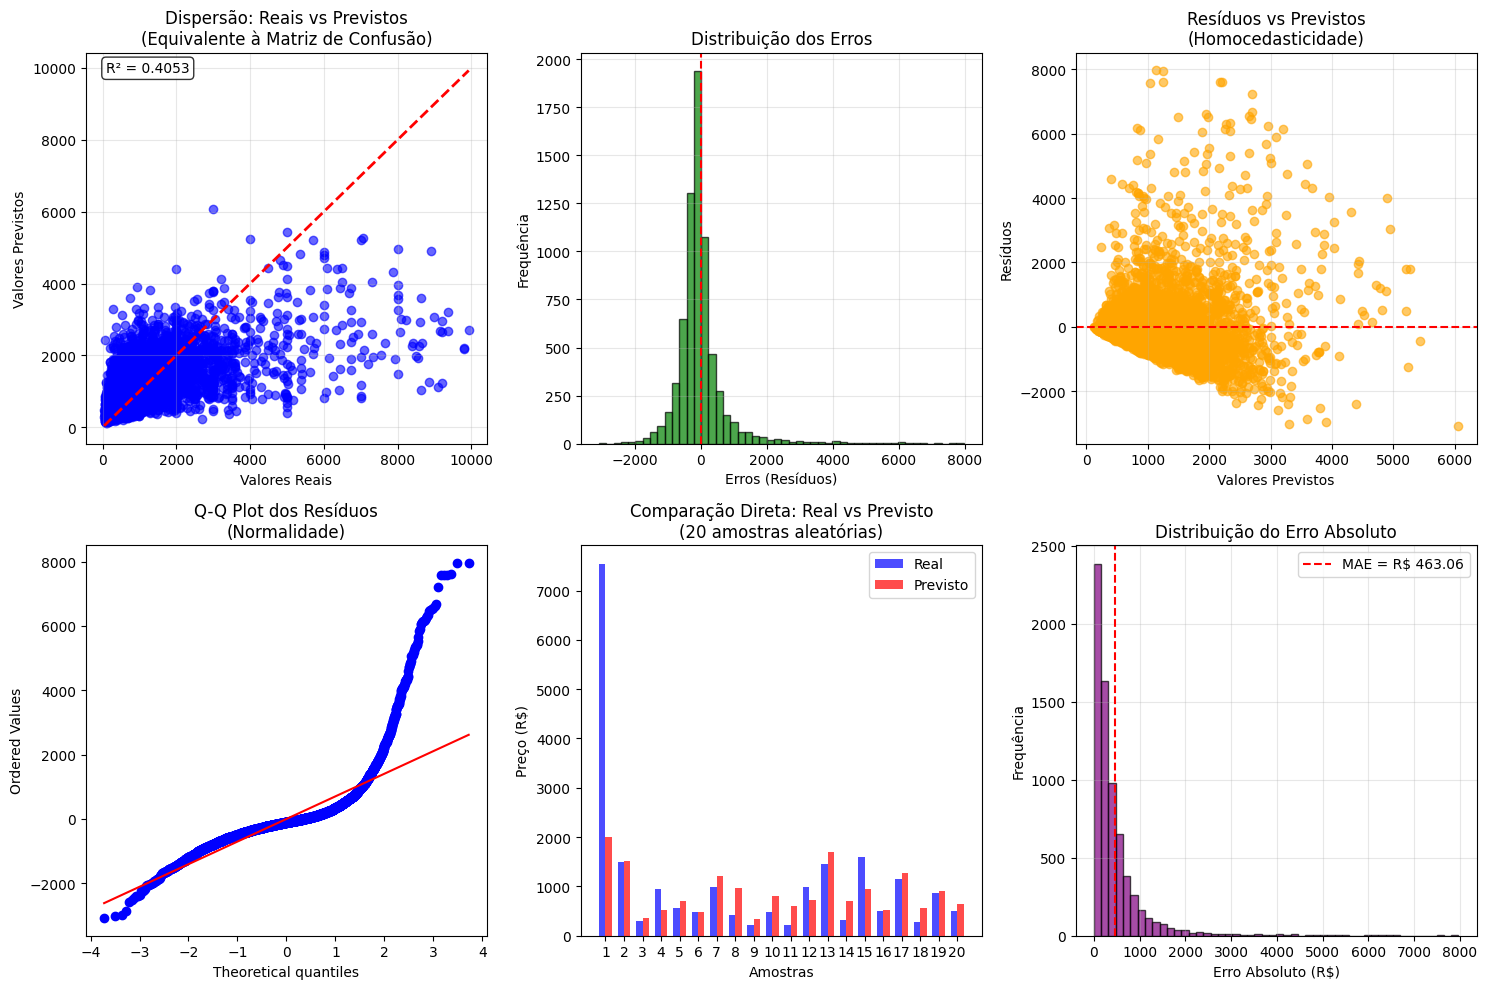

In [94]:
# 📊 VISUALIZAÇÕES EQUIVALENTES À MATRIZ DE CONFUSÃO PARA REGRESSÃO

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("📈 VISUALIZAÇÕES PARA AVALIAR MODELOS DE REGRESSÃO")

# 1. GRÁFICO DE DISPERSÃO: Valores Reais vs Previstos
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.scatter(y_test, y_pred_optimized, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reais')
plt.ylabel('Valores Previstos')
plt.title('Dispersão: Reais vs Previstos\n(Equivalente à Matriz de Confusão)')
plt.grid(True, alpha=0.3)

# Adicionar R² no gráfico
r2 = r2_score(y_test, y_pred_optimized)
plt.text(0.05, 0.95, f'R² = {r2:.4f}', transform=plt.gca().transAxes,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# 2. HISTOGRAMA DOS ERROS (Resíduos)
plt.subplot(2, 3, 2)
residuos = y_test - y_pred_optimized
plt.hist(residuos, bins=50, alpha=0.7, color='green', edgecolor='black')
plt.xlabel('Erros (Resíduos)')
plt.ylabel('Frequência')
plt.title('Distribuição dos Erros')
plt.axvline(x=0, color='red', linestyle='--')
plt.grid(True, alpha=0.3)

# 3. GRÁFICO DE RESÍDUOS vs PREVISTOS
plt.subplot(2, 3, 3)
plt.scatter(y_pred_optimized, residuos, alpha=0.6, color='orange')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Valores Previstos')
plt.ylabel('Resíduos')
plt.title('Resíduos vs Previstos\n(Homocedasticidade)')
plt.grid(True, alpha=0.3)

# 4. GRÁFICO QQ (Normalidade dos Resíduos)
plt.subplot(2, 3, 4)
from scipy import stats
stats.probplot(residuos, dist="norm", plot=plt)
plt.title('Q-Q Plot dos Resíduos\n(Normalidade)')

# 5. COMPARAÇÃO DIRETA (Top 20 amostras)
plt.subplot(2, 3, 5)
indices = np.random.choice(len(y_test), 20, replace=False)
y_test_sample = y_test.iloc[indices]
y_pred_sample = y_pred_optimized[indices]

x_pos = np.arange(len(y_test_sample))
width = 0.35

plt.bar(x_pos - width/2, y_test_sample, width, label='Real', alpha=0.7, color='blue')
plt.bar(x_pos + width/2, y_pred_sample, width, label='Previsto', alpha=0.7, color='red')
plt.xlabel('Amostras')
plt.ylabel('Preço (R$)')
plt.title('Comparação Direta: Real vs Previsto\n(20 amostras aleatórias)')
plt.legend()
plt.xticks(x_pos, [f'{i+1}' for i in range(20)])

# 6. GRÁFICO DE ERRO ABSOLUTO
plt.subplot(2, 3, 6)
erro_absoluto = np.abs(residuos)
plt.hist(erro_absoluto, bins=50, alpha=0.7, color='purple', edgecolor='black')
plt.xlabel('Erro Absoluto (R$)')
plt.ylabel('Frequência')
plt.title('Distribuição do Erro Absoluto')
plt.grid(True, alpha=0.3)

# Adicionar linha da média
mae = mean_absolute_error(y_test, y_pred_optimized)
plt.axvline(x=mae, color='red', linestyle='--', label=f'MAE = R$ {mae:.2f}')
plt.legend()

plt.tight_layout()
plt.show()

1. Dispersão: Reais vs Previstos (equivalente à matriz de confusão):

O gráfico mostra a relação entre os valores reais e os valores previstos pelo modelo. O ajuste parece razoável, já que a linha vermelha, que representa a linha de regressão, passa por muitos pontos, indicando uma boa correspondência entre os valores reais e previstos. O R² = 0.4053 indica que aproximadamente 40,5% da variabilidade nos dados é explicada pelo modelo, o que é um valor moderado.

2. Distribuição dos Erros:

Este histograma mostra a distribuição dos erros (diferença entre os valores reais e previstos). A distribuição parece simétrica e um pouco inclinada para a esquerda, o que é geralmente um bom sinal. Idealmente, os erros devem ser distribuídos normalmente, o que parece ocorrer aqui.

3. Resíduos vs Previstos (Homocedasticidade):

Este gráfico testa a homocedasticidade, ou seja, se a variabilidade dos resíduos é constante ao longo dos valores previstos. O gráfico sugere que os resíduos não mostram uma variação sistemática em relação aos valores previstos, indicando que a homocedasticidade está presente. A linha horizontal na posição 0 também sugere que os resíduos têm uma média próxima de zero.

4. Q-Q Plot dos Resíduos (Normalidade):

O gráfico Q-Q (quantil-quantil) é utilizado para testar a normalidade dos resíduos. A linha reta sugere que os resíduos seguem uma distribuição aproximadamente normal. Embora haja algumas pequenas discrepâncias nas extremidades, a normalidade parece ser uma boa suposição para os erros.

5. Comparação Direta: Real vs Previsto (20 amostras aleatórias):

Este gráfico compara os valores reais e previstos em 20 amostras aleatórias. Pode-se observar que as barras azuis (reais) e vermelhas (previstos) estão relativamente próximas em muitos casos, mas em algumas amostras as diferenças são visíveis, o que sugere que o modelo pode ter alguns erros em certos casos.

6. Distribuição do Erro Absoluto:

O histograma mostra a distribuição do erro absoluto (sem sinal). A média absoluta do erro (MAE) é de R$ 463,06, o que indica o valor médio de erro absoluto entre os valores reais e previstos. A distribuição parece estar concentrada em torno de valores menores, o que é positivo, mas há algumas instâncias com erros muito altos.

Em resumo, o modelo parece estar razoavelmente bem ajustado, mas com margem para melhorias. A homocedasticidade e a normalidade dos erros são positivas, mas a explicação de 40,5% da variabilidade indica que há espaço para aprimorar o ajuste, talvez com a inclusão de mais variáveis ou com outro tipo de transformação.

In [95]:
# 📈 ANÁLISE ESTATÍSTICA DETALHADA

print("📊 ANÁLISE ESTATÍSTICA DOS RESÍDUOS")
print("="*50)

# Estatísticas básicas
print("📋 ESTATÍSTICAS DOS RESÍDUOS:")
print(f"• Média dos resíduos: R$ {residuos.mean():.2f}")
print(f"• Desvio padrão: R$ {residuos.std():.2f}")
print(f"• MAE: R$ {mean_absolute_error(y_test, y_pred_optimized):.2f}")
print(f"• RMSE: R$ {np.sqrt(mean_squared_error(y_test, y_pred_optimized)):.2f}")
print(f"• R²: {r2_score(y_test, y_pred_optimized):.4f}")

# Teste de normalidade
from scipy.stats import shapiro
if len(residuos) > 5000:
    # Para grandes amostras, usar teste em subamostra
    residuos_sample = np.random.choice(residuos, 5000, replace=False)
else:
    residuos_sample = residuos

stat, p_value = shapiro(residuos_sample)
print(f"• Teste de Shapiro-Wilk (normalidade): p = {p_value:.4f}")

if p_value > 0.05:
    print("  ✅ Resíduos seguem distribuição normal")
else:
    print("  ⚠️  Resíduos NÃO seguem distribuição normal")

# Análise de outliers nos resíduos
Q1 = np.percentile(residuos, 25)
Q3 = np.percentile(residuos, 75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = residuos[(residuos < limite_inferior) | (residuos > limite_superior)]
print(f"• Resíduos outliers: {len(outliers)} ({len(outliers)/len(residuos)*100:.1f}%)")

print(f"• Maior superestimação: R$ {residuos.min():.2f}")
print(f"• Maior subestimação: R$ {residuos.max():.2f}")

📊 ANÁLISE ESTATÍSTICA DOS RESÍDUOS
📋 ESTATÍSTICAS DOS RESÍDUOS:
• Média dos resíduos: R$ 0.21
• Desvio padrão: R$ 835.93
• MAE: R$ 463.06
• RMSE: R$ 835.87
• R²: 0.4053
• Teste de Shapiro-Wilk (normalidade): p = 0.0000
  ⚠️  Resíduos NÃO seguem distribuição normal
• Resíduos outliers: 763 (10.8%)
• Maior superestimação: R$ -3076.99
• Maior subestimação: R$ 7966.96


1. Média dos resíduos: R$ 0.21

A média dos resíduos próxima de zero é um bom sinal, indicando que o modelo não tem viés significativo em relação aos valores reais. Ou seja, o modelo não tende a subestimar ou superestimar os valores de maneira consistente.

2. Desvio padrão: R$ 835.93

O desvio padrão relativamente alto indica que há uma grande dispersão nos erros. Isso sugere que o modelo tem uma variação considerável na sua previsão em relação aos valores reais.

3. MAE (Erro Absoluto Médio): R$ 463.06

O MAE é uma medida importante para entender o erro médio do modelo. Esse valor de R$ 463,06 indica que, em média, o modelo está errando em R$ 463,06 por previsão. Embora não seja um valor baixíssimo, o MAE fornece uma ideia de quão distante o modelo está das respostas reais.

4. RMSE (Erro Quadrático Médio): R$ 835.87

O RMSE é uma medida que penaliza mais os erros maiores (já que os erros são elevados ao quadrado). A similaridade entre o RMSE e o desvio padrão dos resíduos (R$ 835.87) sugere que os maiores erros têm um impacto significativo no modelo. Isso é consistente com a grande variação nos erros.

5. R²: 0.4053

O R² de 0.4053 indica que o modelo explica cerca de 40,5% da variabilidade nos dados. Embora isso não seja extremamente alto, é um valor razoável. O modelo poderia ser melhorado para capturar mais variabilidade nos dados, mas ainda é uma explicação significativa.

6. Teste de Shapiro-Wilk (Normalidade): p = 0.0000

O valor p = 0.0000 no teste de normalidade (Shapiro-Wilk) indica que os resíduos não seguem uma distribuição normal. Isso é importante, pois a normalidade dos resíduos é uma suposição para muitos testes e modelos de regressão. A falta de normalidade sugere que o modelo pode ter algumas falhas, ou que há algum padrão nos resíduos que não foi capturado pelo modelo.

7. Resíduos Outliers: 763 (10.8%)

A presença de 10,8% de outliers nos resíduos é significativa. Outliers podem indicar que o modelo não está capturando corretamente certas variações nos dados ou que há influências externas que afetam as previsões de forma inesperada.

8. Maior Superestimação: R$ -3076.99

A maior superestimação (erro negativo) foi R$ -3076,99, ou seja, o modelo superestimou um valor real em R$ 3076,99. Isso é um erro considerável.

9. Maior Subestimação: R$ 7966.96

A maior subestimação foi de R$ 7966,96, o que também é um erro considerável, e é muito maior que a maior superestimação. Isso indica que o modelo tem um problema de subestimar alguns casos de forma significativa.

Conclusões:

O modelo apresenta um erro médio razoável (MAE), mas há uma grande variação nos erros, como indicado pelo desvio padrão e pelo RMSE.

A normalidade dos resíduos não é atendida, o que pode indicar que o modelo pode ser melhorado ou que outro tipo de modelo poderia ser mais adequado.

A presença de outliers e grandes erros de superestimação e subestimação sugere que, em alguns casos, o modelo tem dificuldades em capturar a relação correta entre as variáveis.


🔍 CORRELAÇÃO ENTRE ERROS E FEATURES PRINCIPAIS
📊 Features com maior correlação com os erros:
• accommodates              | Correlação:  0.0716
• number_of_reviews         | Correlação: -0.0268
• reviews_per_month         | Correlação: -0.0099
• longitude                 | Correlação:  0.0097
• latitude                  | Correlação: -0.0065


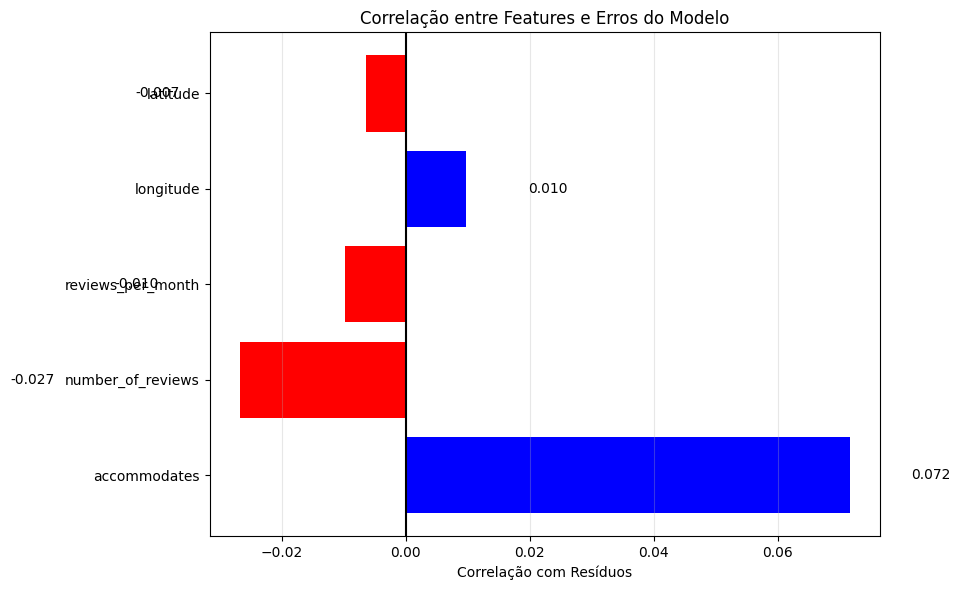

In [96]:
# 🔍 MATRIZ DE CORRELAÇÃO ENTRE ERROS E FEATURES

print("\n🔍 CORRELAÇÃO ENTRE ERROS E FEATURES PRINCIPAIS")

# Selecionar features numéricas importantes
features_numericas = X.select_dtypes(include=[np.number]).columns

# Calcular correlação entre resíduos e features
correlacoes = []
for feature in features_numericas[:10]:  # Apenas as 10 primeiras
    correl = np.corrcoef(X_test[feature], residuos)[0, 1]
    if not np.isnan(correl):
        correlacoes.append((feature, abs(correl), correl))

# Ordenar por correlação absoluta
correlacoes.sort(key=lambda x: x[1], reverse=True)

print("📊 Features com maior correlação com os erros:")
for feature, corr_abs, corr in correlacoes[:5]:
    print(f"• {feature:25} | Correlação: {corr:7.4f}")

# Gráfico de correlação
if len(correlacoes) > 0:
    features, correl_abs, correl = zip(*correlacoes[:8])

    plt.figure(figsize=(10, 6))
    bars = plt.barh(features, correl, color=['red' if x < 0 else 'blue' for x in correl])
    plt.xlabel('Correlação com Resíduos')
    plt.title('Correlação entre Features e Erros do Modelo')
    plt.axvline(x=0, color='black', linestyle='-')
    plt.grid(True, alpha=0.3, axis='x')

    # Adicionar valores
    for bar, valor in zip(bars, correl):
        plt.text(bar.get_width() + (0.01 if valor >= 0 else -0.03),
                bar.get_y() + bar.get_height()/2,
                f'{valor:.3f}',
                ha='left' if valor >= 0 else 'right',
                va='center')

    plt.tight_layout()
    plt.show()

Análise do gráfico:

1. Accommodates (correlação de 0.0716):

A variável accommodates (número de acomodações) tem a maior correlação positiva com os erros. Isso sugere que, à medida que o número de acomodações aumenta, o modelo tende a errar ligeiramente mais nas previsões. A correlação é relativamente baixa, mas ainda assim significativa em termos de tendência.

2. Number_of_reviews (correlação de -0.0268):

A variável number_of_reviews (número de avaliações) tem uma correlação negativa muito pequena com os erros. Isso significa que, em alguns casos, um maior número de avaliações pode estar associado a menores erros nas previsões, mas a relação é muito fraca. A correlação negativa sugere que o modelo pode estar mais preciso para aqueles com mais avaliações, mas a variação é mínima.

3. Reviews_per_month (correlação de -0.0099):

Reviews_per_month (número de avaliações por mês) tem uma correlação muito próxima de zero, o que indica que não há uma relação clara entre essa variável e os erros do modelo. Isso sugere que o modelo não é sensível a essa variável em particular.

4. Longitude (correlação de 0.0097):

Longitude tem uma correlação muito baixa e positiva com os erros. Isso indica que a localização geográfica (longitude) tem uma influência quase nula sobre a magnitude dos erros do modelo.

5. Latitude (correlação de -0.0065):

Latitude também apresenta uma correlação muito baixa, mas negativa, com os erros. Isso sugere que a variável latitude tem um impacto praticamente irrelevante nos erros do modelo, com uma relação mínima.

Conclusão:

A correlação entre as features e os erros do modelo é muito baixa em todas as variáveis, o que indica que essas características não estão influenciando significativamente os erros de previsão. A maior correlação está em accommodates, mas ainda assim, ela é pequena. Isso sugere que o modelo está basicamente capturando as relações principais, mas outras variáveis podem precisar de ajustes ou podem ser irrelevantes para o ajuste do modelo.

Além disso, é importante observar que a maioria das correlações é muito baixa, o que significa que o modelo pode não estar utilizando essas variáveis de forma eficiente. Isso poderia ser um indicativo de que o modelo precisa ser ajustado ou que outras variáveis mais relevantes poderiam ser incluídas.


## 12. Conclusões e próximos passos
**TODO:** Resuma resultados, trade-offs, e proponha melhorias futuras (mais dados, features, modelos, tuning).



## 13. Salvando artefatos (modelos e pipeline)
Se o treinamento dos modelos demora mais de 3 minutos, recomendamos salvar o **modelo/pipeline** após o treinamento e depois apenas carregar o arquivo (ex: .pkl, .h5) salvo em outra célula, sem precisar treinar novamente.  